# 02_b_binary_codes.ipynb

生成 `02_a_binary_lec.qmd` 中所需图片，并将模拟数据保存到 `./data/`。

**图片列表**
- `fig01_scatter.png`：三联图（散点 + 两个箱线图）
- `fig02_lpm_vs_logit.png`：LPM vs Logit 拟合概率对比
- `fig03_link_functions.png`：三种链接函数对比
- `fig04_roc_confusion.png`：ROC 曲线 + 混淆矩阵
- `fig05_confounding.png`：混淆变量分析
- `fig_latent_variable.png`：潜变量 Y* 与观测值 Y 的关系

**数据**
- `./data/corporate_default.csv`：1000家公司的模拟数据

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix
import statsmodels.api as sm
import warnings, os
warnings.filterwarnings('ignore')

# 中文支持
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

os.makedirs('./figs', exist_ok=True)
os.makedirs('./data', exist_ok=True)

plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'figure.dpi': 150,
})
BLUE, ORANGE, GRAY = '#3B8BD4', '#D85A30', '#888780'

## 1. 数据生成（DGP）

**关键设计**：引入连续变量之间的相关性，使模拟数据更接近真实公司财务数据。

真实规律：
- 大公司（Size 高）→ ROA 更高、Leverage 更低（规模经济 + 更强的融资能力）
- 国有企业 → Size 更大、Leverage 较低
- 地产行业 → Leverage 更高

用 Cholesky 分解控制连续变量的相关矩阵。

In [17]:
np.random.seed(42)
N = 1000

# ── 1.1 连续变量：通过相关矩阵生成 ──────────────────────────
# 变量顺序：[size, leverage, roa, age]
# 相关矩阵（基于金融数据的经验规律）：
#   size & leverage:  -0.30  （大公司杠杆更低）
#   size & roa:       +0.25  （大公司盈利能力稍强）
#   size & age:       +0.40  （老牌公司规模更大）
#   leverage & roa:   -0.20  （高杠杆公司盈利往往较弱）
#   leverage & age:   -0.10  （成熟公司杠杆略低）
#   roa & age:        +0.10
corr_matrix = np.array([
    [1.00, -0.30,  0.25,  0.40],
    [-0.30,  1.00, -0.20, -0.10],
    [0.25, -0.20,  1.00,  0.10],
    [0.40, -0.10,  0.10,  1.00]
])

# Cholesky 分解生成相关的标准正态随机数
L = np.linalg.cholesky(corr_matrix)
Z = np.random.standard_normal((4, N))
corr_Z = (L @ Z).T   # shape: (N, 4)

# 转换为实际变量的边际分布
size = 8.0 + 1.8 * corr_Z[:, 0]                                    # N(8, 1.8²)
lev  = np.clip(0.45 + 0.18 * corr_Z[:, 1], 0.05, 0.95)            # 截断到[0.05, 0.95]
roa  = np.clip(0.05 + 0.025 * corr_Z[:, 2], -0.10, 0.20)          # 截断到[-0.1, 0.2]
age  = np.clip(10 + 7 * corr_Z[:, 3], 1, 35).round().astype(float) # 1~35年

# ── 1.2 类别变量 ──────────────────────────────────────────────
industry  = np.random.choice(
    ['manufacturing', 'real_estate', 'finance', 'tech'],
    N, p=[0.40, 0.20, 0.20, 0.20])
ownership = np.random.choice(['state', 'private'], N, p=[0.40, 0.60])

# 国有企业 Size 整体偏大（+0.5），地产行业 Leverage 偏高（+0.08）
size_adj = size + np.where(ownership == 'state', 0.5, 0.0)

# 国有企业 Leverage 整体偏低（-0.08），民营企业偏高（+0.08）
# 地产行业额外加 0.06
lev_adj = np.clip(
    lev
    + np.where(ownership == 'state',        -0.08, +0.08)
    + np.where(industry  == 'real_estate',   0.06,  0.00),
    0.05, 0.95
)

# ── 1.3 因变量：基于 logit DGP ───────────────────────────────
ind_fx = {'manufacturing': 0.0, 'real_estate': 0.5, 'finance': -0.3, 'tech': 0.2}
own_fx = {'state': -0.4, 'private': 0.2}

logit_v = (
    -2.5
    - 0.60 * (size_adj - 8)
    + 4.00 * (lev_adj  - 0.45)
    - 8.00 * (roa      - 0.05)
    - 0.05 * (age      - 10)
    + np.array([ind_fx[i] for i in industry])
    + np.array([own_fx[o] for o in ownership])
)

prob    = expit(logit_v)
default = (np.random.uniform(0, 1, N) < prob).astype(int)

df = pd.DataFrame({
    'default':   default,
    'size':      size_adj.round(4),
    'leverage':  lev_adj.round(4),
    'roa':       roa.round(4),
    'age':       age,
    'industry':  industry,
    'ownership': ownership
})

print(f'N={N}  |  违约样本: {default.sum()}  |  违约率: {default.mean():.1%}')
print('\n相关矩阵（实际生成）：')
print(df[['size','leverage','roa','age']].corr().round(2))

N=1000  |  违约样本: 163  |  违约率: 16.3%

相关矩阵（实际生成）：
          size  leverage   roa   age
size      1.00     -0.33  0.27  0.36
leverage -0.33      1.00 -0.21 -0.11
roa       0.27     -0.21  1.00  0.13
age       0.36     -0.11  0.13  1.00


In [18]:
# ── 1.4 保存数据 ──────────────────────────────────────────────
df.to_csv('./data/corporate_default.csv', index=False)
print('数据已保存到 ./data/corporate_default.csv')
print(f'数据维度: {df.shape}')
print(df.head().round(2))

数据已保存到 ./data/corporate_default.csv
数据维度: (1000, 7)
   default   size  leverage   roa   age       industry ownership
0        0   9.39      0.64  0.03   1.0    real_estate     state
1        1   7.75      0.70  0.04   4.0  manufacturing   private
2        0   9.67      0.35  0.03   9.0           tech     state
3        0  11.24      0.24  0.05  26.0    real_estate     state
4        0   8.08      0.50  0.00  13.0        finance     state


## 2. fig01：三联图（复现 James Figure 4.1 的结构）

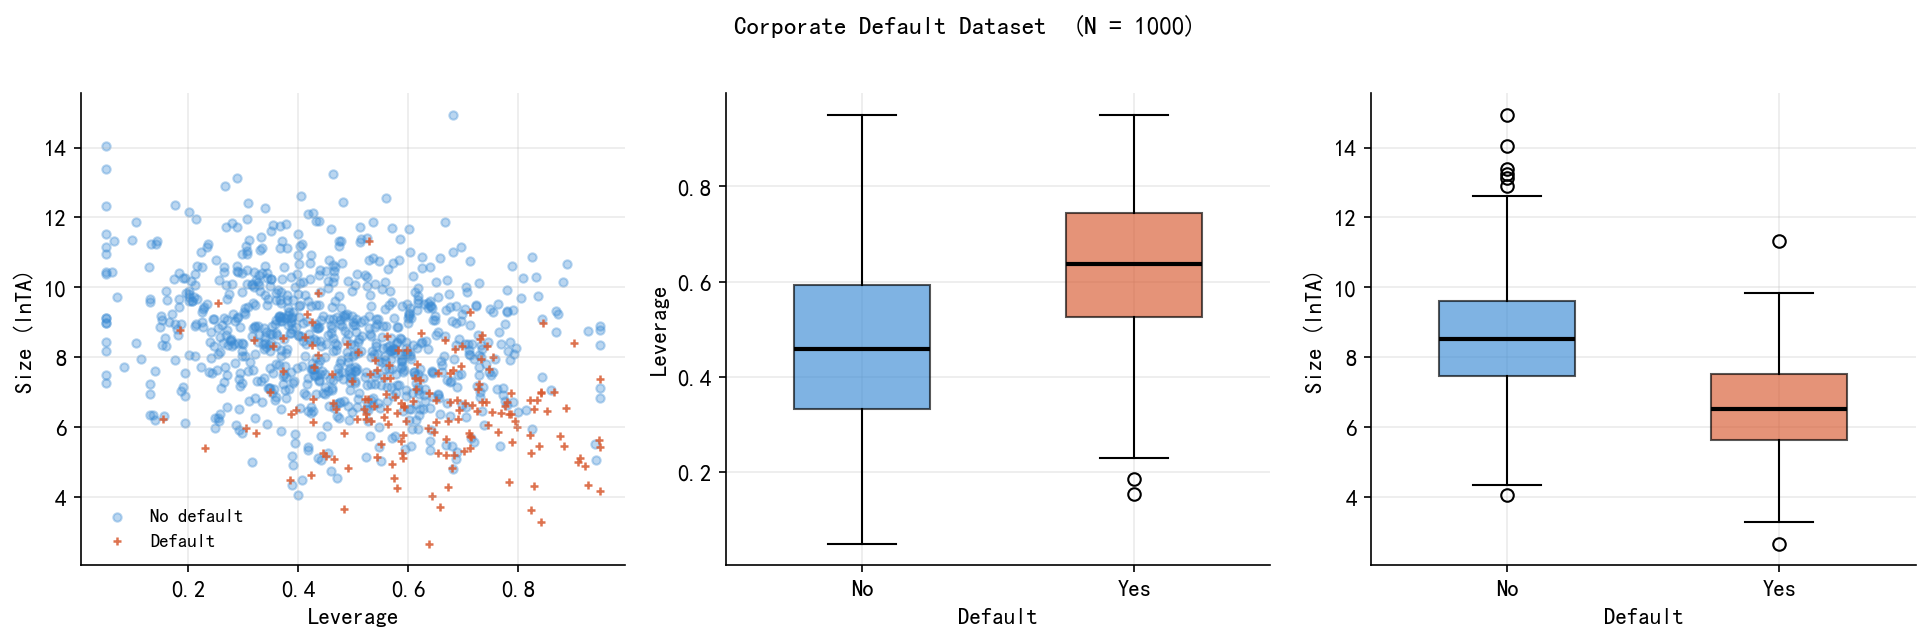

Saved: fig01_scatter.png


In [22]:
d0, d1 = df[df.default==0], df[df.default==1]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

# 左：散点图
ax = axes[0]
ax.scatter(d0.leverage, d0['size'], alpha=0.35, s=16, color=BLUE,
           marker='o', label='No default')
ax.scatter(d1.leverage, d1['size'], alpha=0.85, s=16, color=ORANGE,
           marker='+', linewidths=1.2, label='Default')
ax.set_xlabel('Leverage')
ax.set_ylabel('Size (lnTA)')
ax.legend(frameon=False, fontsize=9, loc='lower left')

# 中：Leverage 箱线图
for ax, var, ylabel in [
    (axes[1], 'leverage', 'Leverage'),
    (axes[2], 'size',     'Size (lnTA)')
]:
    bp = ax.boxplot(
        [d0[var].values, d1[var].values],
        patch_artist=True, widths=0.5,
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set(facecolor=BLUE,   alpha=0.65)
    bp['boxes'][1].set(facecolor=ORANGE, alpha=0.65)
    ax.set_xticklabels(['No', 'Yes'])
    ax.set_xlabel('Default')
    ax.set_ylabel(ylabel)

plt.suptitle('Corporate Default Dataset  (N = 1000)', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('./figs/fig01_scatter.png', bbox_inches='tight')
plt.show()
print('Saved: fig01_scatter.png')

## 3. fig02：LPM vs Logit 拟合概率对比

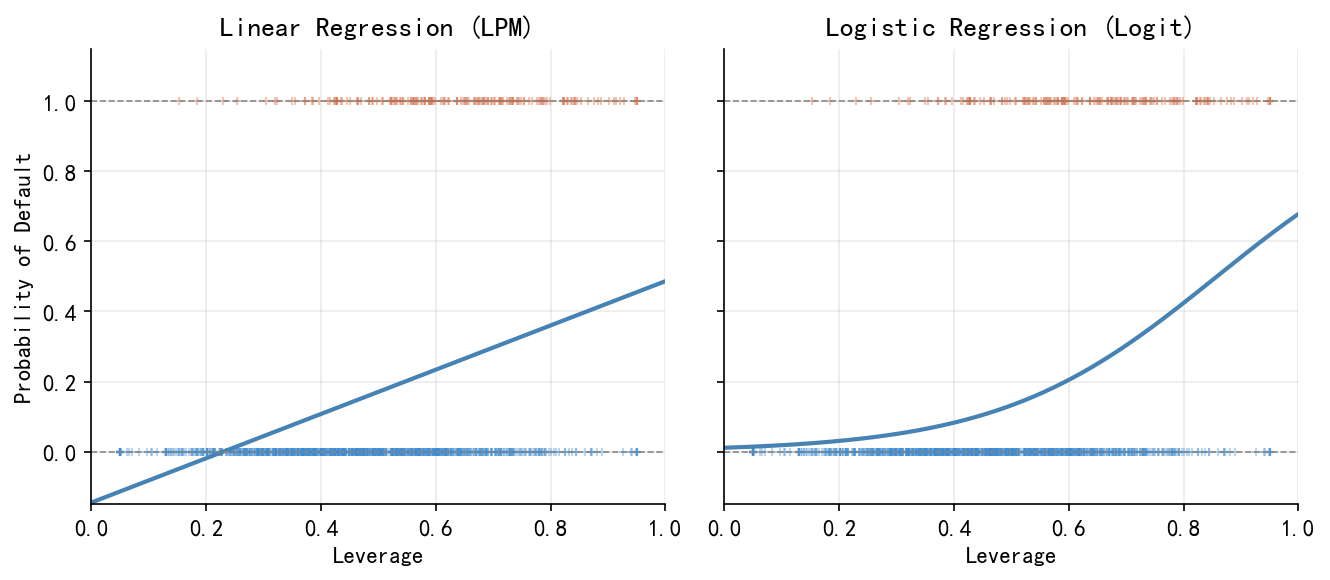

Saved: fig02_lpm_vs_logit.png


In [5]:
y = df['default'].values
X1 = sm.add_constant(df[['leverage']])
lpm_m   = sm.OLS(y, X1).fit()
logit_m = sm.Logit(y, X1).fit(disp=0)

lev_g  = np.linspace(0.0, 1.0, 300)
X_grid = sm.add_constant(pd.DataFrame({'leverage': lev_g}))

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

for ax, probs, title in zip(
    axes,
    [lpm_m.predict(X_grid), logit_m.predict(X_grid)],
    ['Linear Regression (LPM)', 'Logistic Regression (Logit)']
):
    for yi, col in [(0, BLUE), (1, ORANGE)]:
        mask = y == yi
        ax.plot(df.leverage[mask], np.full(mask.sum(), yi),
                '+', color=col, alpha=0.35, markersize=4)
    ax.plot(lev_g, probs, color='steelblue', lw=2)
    ax.axhline(0, color=GRAY, lw=0.8, ls='--')
    ax.axhline(1, color=GRAY, lw=0.8, ls='--')
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.15, 1.15)
    ax.set_xlabel('Leverage')
    ax.set_title(title)

axes[0].set_ylabel('Probability of Default')
plt.tight_layout()
plt.savefig('./figs/fig02_lpm_vs_logit.png', bbox_inches='tight')
plt.show()
print('Saved: fig02_lpm_vs_logit.png')

## 4. fig03：三种链接函数对比

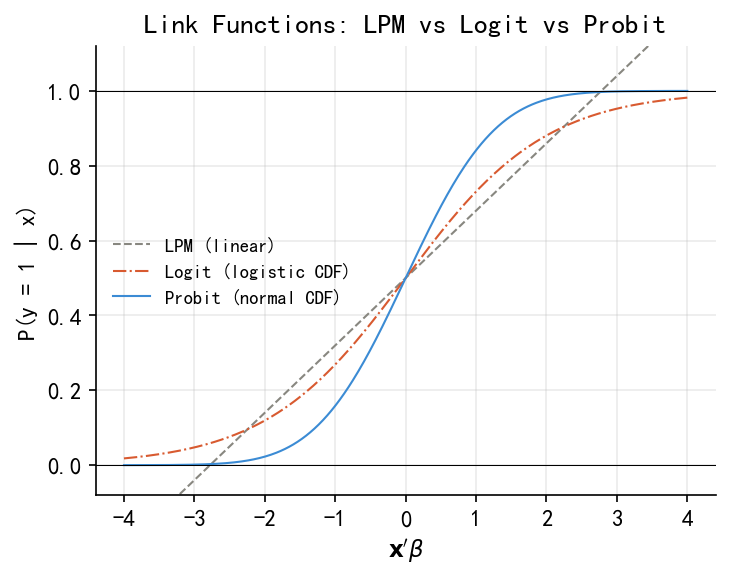

Saved: fig03_link_functions.png


In [11]:
u = np.linspace(-4, 4, 400)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(u, 0.5 + 0.18*u,     lw=1, ls='--', color=GRAY,   label='LPM (linear)')
ax.plot(u, expit(u),         lw=1, ls='-.', color=ORANGE, label='Logit (logistic CDF)')
ax.plot(u, stats.norm.cdf(u),lw=1, ls='-',  color=BLUE,  label='Probit (normal CDF)')
ax.axhline(0, color='black', lw=0.5)
ax.axhline(1, color='black', lw=0.5)
ax.set_xlabel("$\\mathbf{x}'\\beta$")
ax.set_ylabel('P(y = 1 | x)')
ax.set_ylim(-0.08, 1.12)
ax.legend(frameon=False, fontsize=9, loc='center left')
ax.set_title('Link Functions: LPM vs Logit vs Probit')
plt.tight_layout()
plt.savefig('./figs/fig03_link_functions.png', bbox_inches='tight')
plt.show()
print('Saved: fig03_link_functions.png')

## 5. fig_latent_variable：潜变量 Y* 与观测 Y（新增）

复现你的 Stata 图形（Logit-Latent-variable-01 和 02），但合并成一张宽图。

DGP：$Y^* = -3 + 0.6x + e$，$e \sim N(0,1)$，$x \sim U(0,10)$

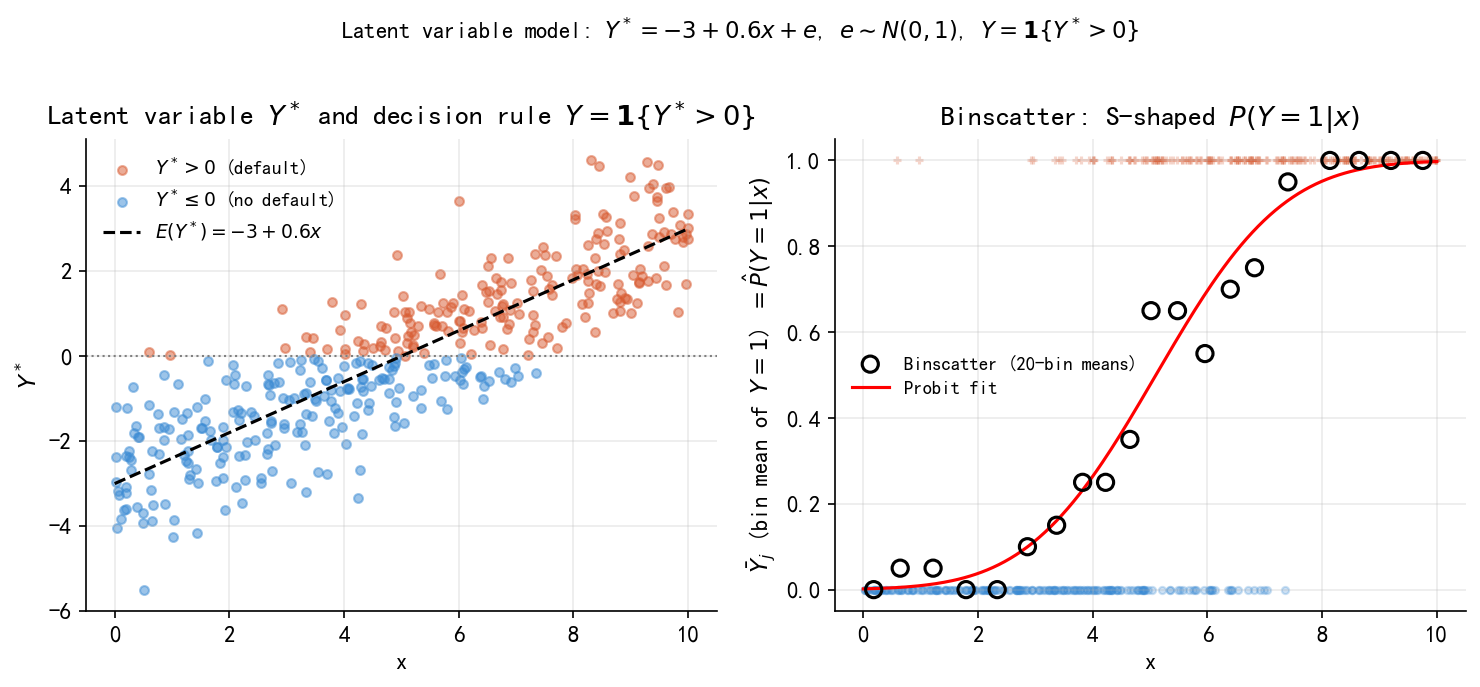

Saved: fig_latent_variable.png


In [12]:

np.random.seed(12348)   # consistent with Stata seed
n_lat = 400
x_lat   = np.random.uniform(0, 10, n_lat)
e_lat   = np.random.normal(0, 1, n_lat)
ystar   = -3 + 0.6 * x_lat + e_lat
y_lat   = (ystar > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# ── Left: scatter of Y* and Y ────────────────────────────────
ax = axes[0]
ax.scatter(x_lat[ystar>0],  ystar[ystar>0],  alpha=0.5, s=18,
           color=ORANGE, label='$Y^*>0$ (default)')
ax.scatter(x_lat[ystar<=0], ystar[ystar<=0], alpha=0.5, s=18,
           color=BLUE,   label='$Y^*\\leq 0$ (no default)')
xfit = np.linspace(0, 10, 200)
ax.plot(xfit, -3 + 0.6*xfit, color='black', lw=1.5, ls='--', label='$E(Y^*)=-3+0.6x$')
ax.axhline(0, color='gray', lw=1, ls=':')
ax.set_xlabel('x')
ax.set_ylabel('$Y^*$')
ax.set_title('Latent variable $Y^*$ and decision rule $Y=\\mathbf{1}\\{Y^*>0\\}$')
ax.legend(frameon=False, fontsize=9)

# ── Right: binscatter (20 bins) ──────────────────────────────
ax = axes[1]
ax.scatter(x_lat[y_lat==1], y_lat[y_lat==1], color=ORANGE,
           alpha=0.25, s=12, marker='+')
ax.scatter(x_lat[y_lat==0], y_lat[y_lat==0], color=BLUE,
           alpha=0.25, s=12, marker='o')

lat_df = pd.DataFrame({'x': x_lat, 'y': y_lat})
lat_df['bin'] = pd.qcut(lat_df['x'], 20, labels=False)
bins = lat_df.groupby('bin').agg(xmid=('x','mean'), ymean=('y','mean'))
ax.scatter(bins['xmid'], bins['ymean'], color='black', s=60,
           marker='o', facecolors='none', linewidths=1.5,
           zorder=5, label='Binscatter (20-bin means)')

probit_lat = sm.Probit(y_lat, sm.add_constant(x_lat)).fit(disp=0)
x_probit = np.linspace(0, 10, 200)
p_probit  = probit_lat.predict(sm.add_constant(x_probit))
ax.plot(x_probit, p_probit, color='red', lw=1.5, ls='-', label='Probit fit')

ax.set_xlabel('x')
ax.set_ylabel('$\\bar{Y}_j$ (bin mean of $Y=1$) $= \\hat{P}(Y=1|x)$')
ax.set_title('Binscatter: S-shaped $P(Y=1|x)$')
ax.legend(frameon=False, fontsize=9, loc='center left')

plt.suptitle('Latent variable model: $Y^*=-3+0.6x+e$, $e\\sim N(0,1)$, $Y=\\mathbf{1}\\{Y^*>0\\}$',
             y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig('./figs/fig_latent_variable.png', bbox_inches='tight')
plt.show()
print('Saved: fig_latent_variable.png')


## 6. fig04：ROC + 混淆矩阵

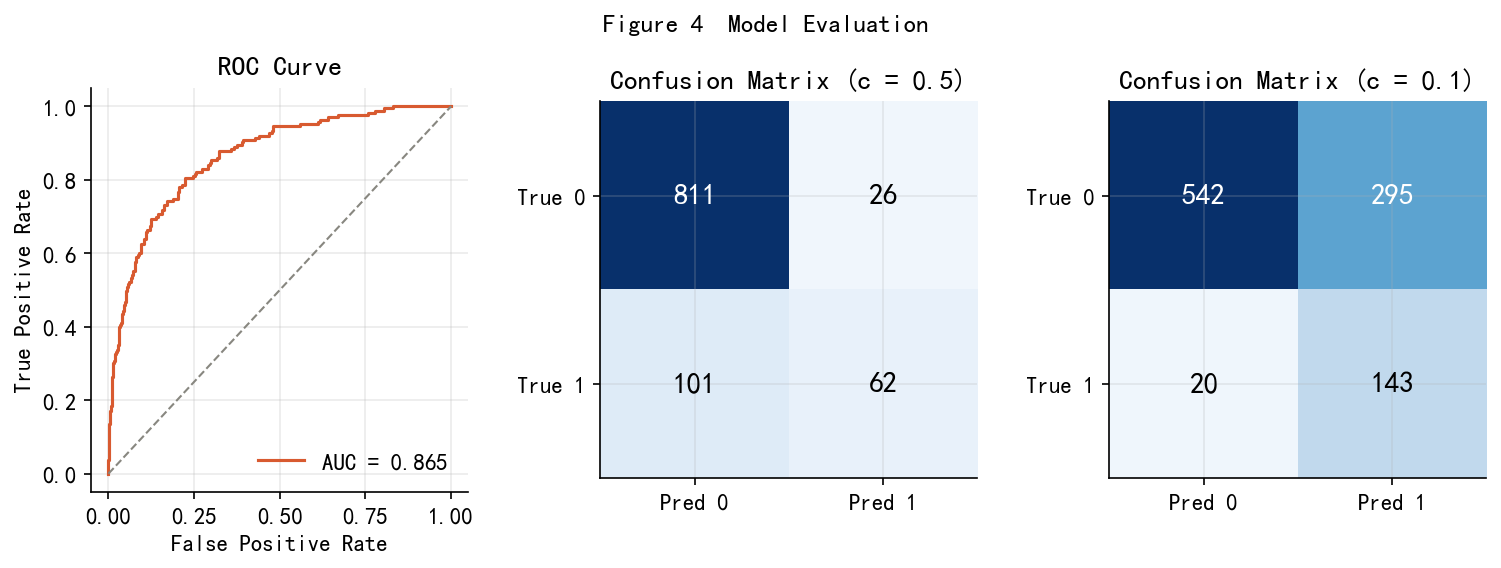

AUC = 0.865
Saved: fig04_roc_confusion.png


In [13]:
# 拟合多变量 Logit
df_tmp = df.copy()
df_tmp['industry'] = pd.Categorical(
    df_tmp['industry'],
    categories=['manufacturing', 'real_estate', 'finance', 'tech']
)
df_tmp['ownership'] = pd.Categorical(
    df_tmp['ownership'],
    categories=['private', 'state']
)

df_enc = pd.get_dummies(df_tmp, columns=['industry', 'ownership'], drop_first=True)
feat_cols = ['size', 'leverage', 'roa', 'age',
             'industry_real_estate', 'industry_finance', 'industry_tech',
             'ownership_state']
X_full = sm.add_constant(df_enc[feat_cols].astype(float))
logit_full = sm.Logit(df['default'].values, X_full).fit(disp=0)
prob_pred  = logit_full.predict(X_full)

# ROC
fpr, tpr, thresholds = roc_curve(y, prob_pred)
roc_auc = auc(fpr, tpr)

# 混淆矩阵（两个阈值）
cm_05 = confusion_matrix(y, (prob_pred > 0.5).astype(int))
cm_01 = confusion_matrix(y, (prob_pred > 0.1).astype(int))

fig = plt.figure(figsize=(12, 3.5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── ROC ──────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
ax0.plot(fpr, tpr, color=ORANGE, lw=1.5, label=f'AUC = {roc_auc:.3f}')
ax0.plot([0,1],[0,1], color=GRAY, ls='--', lw=1)
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.set_title('ROC Curve')
ax0.legend(frameon=False)

# ── 混淆矩阵（阈值 0.5）────────────────────────────────────
for ax, cm, thresh in [
    (fig.add_subplot(gs[1]), cm_05, 0.5),
    (fig.add_subplot(gs[2]), cm_01, 0.1)
]:
    im = ax.imshow(cm, cmap='Blues', vmin=0)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred 0','Pred 1'])
    ax.set_yticklabels(['True 0','True 1'])
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[r,c] > cm.max()/2 else 'black')
    ax.set_title(f'Confusion Matrix (c = {thresh})')

plt.suptitle('Figure 4  Model Evaluation', y=1.02, fontsize=12)
plt.savefig('./figs/fig04_roc_confusion.png', bbox_inches='tight')
plt.show()
print(f'AUC = {roc_auc:.3f}')
print('Saved: fig04_roc_confusion.png')

## 7. fig05：混淆变量（所有制 × 违约率 × Leverage）

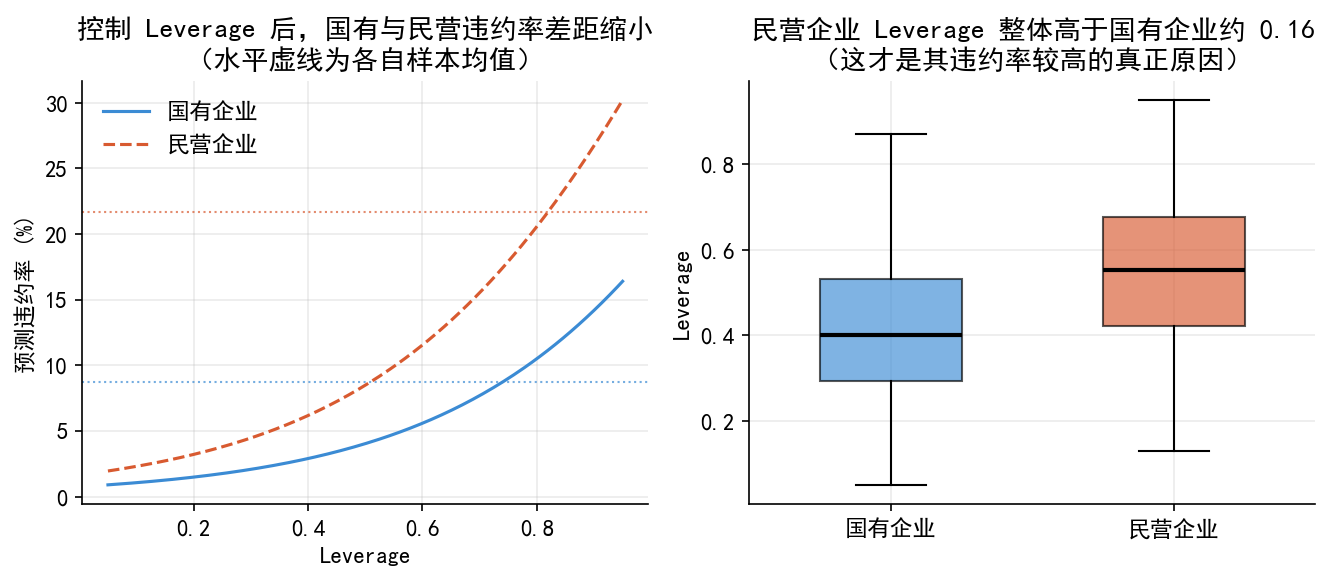

Saved: fig05_confounding.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# 左图：条件违约率曲线
ax = axes[0]
lev_range = np.linspace(0.05, 0.95, 200)

base_xb = (logit_full.params['const']
           + logit_full.params['size']    * df['size'].mean()
           + logit_full.params['roa']     * df['roa'].mean()
           + logit_full.params['age']     * df['age'].mean())
lev_coef  = logit_full.params['leverage']
own_coef  = logit_full.params.get('ownership_state', 0)

for own, col, ls, label in [
    ('state',   BLUE,   '-',  '国有企业'),
    ('private', ORANGE, '--', '民营企业')
]:
    adj = own_coef if own == 'state' else 0
    p   = expit(base_xb + adj + lev_coef * lev_range)
    ax.plot(lev_range, p * 100, color=col, ls=ls, lw=1.5, label=label)

for own, col in [('state', BLUE), ('private', ORANGE)]:
    mr = df[df.ownership==own]['default'].mean() * 100
    ax.axhline(mr, color=col, lw=1, ls=':', alpha=0.7)

ax.set_xlabel('Leverage')
ax.set_ylabel('预测违约率 (%)')
ax.set_title('控制 Leverage 后，国有与民营违约率差距缩小\n（水平虚线为各自样本均值）')
ax.legend(frameon=False)

# 右图：Leverage 分布箱线图
ax = axes[1]
state_lev   = df[df.ownership=='state']['leverage']
private_lev = df[df.ownership=='private']['leverage']
bp = ax.boxplot([state_lev.values, private_lev.values],
                patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set(facecolor=BLUE,   alpha=0.65)
bp['boxes'][1].set(facecolor=ORANGE, alpha=0.65)
ax.set_xticklabels(['国有企业', '民营企业'])
ax.set_ylabel('Leverage')
ax.set_title('民营企业 Leverage 整体高于国有企业约 0.16\n（这才是其违约率较高的真正原因）')

plt.tight_layout()
plt.savefig('./figs/fig05_confounding.png', bbox_inches='tight')
plt.show()
print('Saved: fig05_confounding.png')

## 8. 验证：描述统计与相关矩阵

In [10]:
print('=== 全样本描述统计 ===')
print(df[['size','leverage','roa','age']].describe().round(3))

print('\n=== 违约 vs 未违约：均值对比 ===')
print(df.groupby('default')[['size','leverage','roa','age']].mean().round(3))

print('\n=== 连续变量相关矩阵 ===')
print(df[['size','leverage','roa','age']].corr().round(2))

print('\n=== 所有制 × 违约状态 ===')
print(pd.crosstab(df['ownership'], df['default'], normalize='index').round(3))

=== 全样本描述统计 ===
           size  leverage       roa       age
count  1000.000  1000.000  1000.000  1000.000
mean      8.242     0.488     0.050    10.262
std       1.768     0.192     0.025     6.547
min       2.666     0.050    -0.032     1.000
25%       6.991     0.353     0.033     5.000
50%       8.267     0.485     0.050    10.000
75%       9.394     0.618     0.067    15.000
max      14.935     0.950     0.149    31.000

=== 违约 vs 未违约：均值对比 ===
          size  leverage    roa     age
default                                
0        8.570     0.461  0.052  10.802
1        6.557     0.630  0.041   7.491

=== 连续变量相关矩阵 ===
          size  leverage   roa   age
size      1.00     -0.33  0.27  0.36
leverage -0.33      1.00 -0.21 -0.11
roa       0.27     -0.21  1.00  0.13
age       0.36     -0.11  0.13  1.00

=== 所有制 × 违约状态 ===
default        0      1
ownership              
private    0.783  0.217
state      0.913  0.087
